In [4]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [1]:
def get_hist_df_dataframe(filename):
    file = uproot.open(filename)
    tree = file["hist_df"]

    df = tree.arrays(library="pd")

    # -----------------------------
    # 2. Convert ROOT format → hist_df format
    # -----------------------------
    hist_df = pd.DataFrame({
        1: df["ge_1"],
        2: df["ge_2"],
        3: df["ge_3"],
        4: df["ge_4"],
        5: df["ge_5"],
        6: df["ge_6"],
        7: df["ge_7"],
        8: df["ge_8"],
    })

    # use Ring as index (same as pandas version)
    hist_df.index = df["Ring"]
    hist_df = hist_df.sort_index()

    return hist_df
    

In [2]:
!ls

18_Feb_2026    4_march_2026		       ring_maping.pdf
28_April_2026  creating_plots_histogram.ipynb  save_to_paraquet.ipynb


In [3]:
from IPython.display import IFrame

IFrame("ring_maping.pdf", width=800, height=600)

In [14]:
! ls ../Histogram_files/28_April_2026/Background_Data

hist_Counts_50000_5min_10ns_csv_grouping2.root
hist_Counts_50000_5min_10ns_csv.root
hist_Counts_50000_5min_2ns_csv_grouping2.root


In [8]:
# -----------------------------
# 1. Read ROOT file
# -----------------------------
hist_df_Thresh230_5min = get_hist_df_dataframe("../Histogram_files/28_April_2026/Background_Data/hist_Counts_50000_5min_10ns_csv_grouping2.root")

print(hist_df_Thresh230_5min)

            1        2        3        4        5       6       7       8
Ring                                                                     
1     3268675   880119   692838    87558     4372     700     491     382
2     4164730  1828118  1151176   698228   126921   19919    1974     554
3     1854571   771437   711554   703560   702057  700898  698182  690886
4     2899083  1560091  1002059   867898   710811  694008  513198   89060
5           0        0        0        0        0       0       0       0
6     2919075  1524161  1240157  1131847  1026412  768622  599953  449364
7     2819730   357182   263820   230897   187792   56532   10909    1786
8     1867241    68587    13198     3865      184      74      55      35
9     1415662    45785    10332     4878      295     152      85      54
10    2010725   142369    63950    30221     8285    2576     663     140
11    2367791   240506   201278   158947    95967   48005    8387    2554
12     391764    13609     6790     58

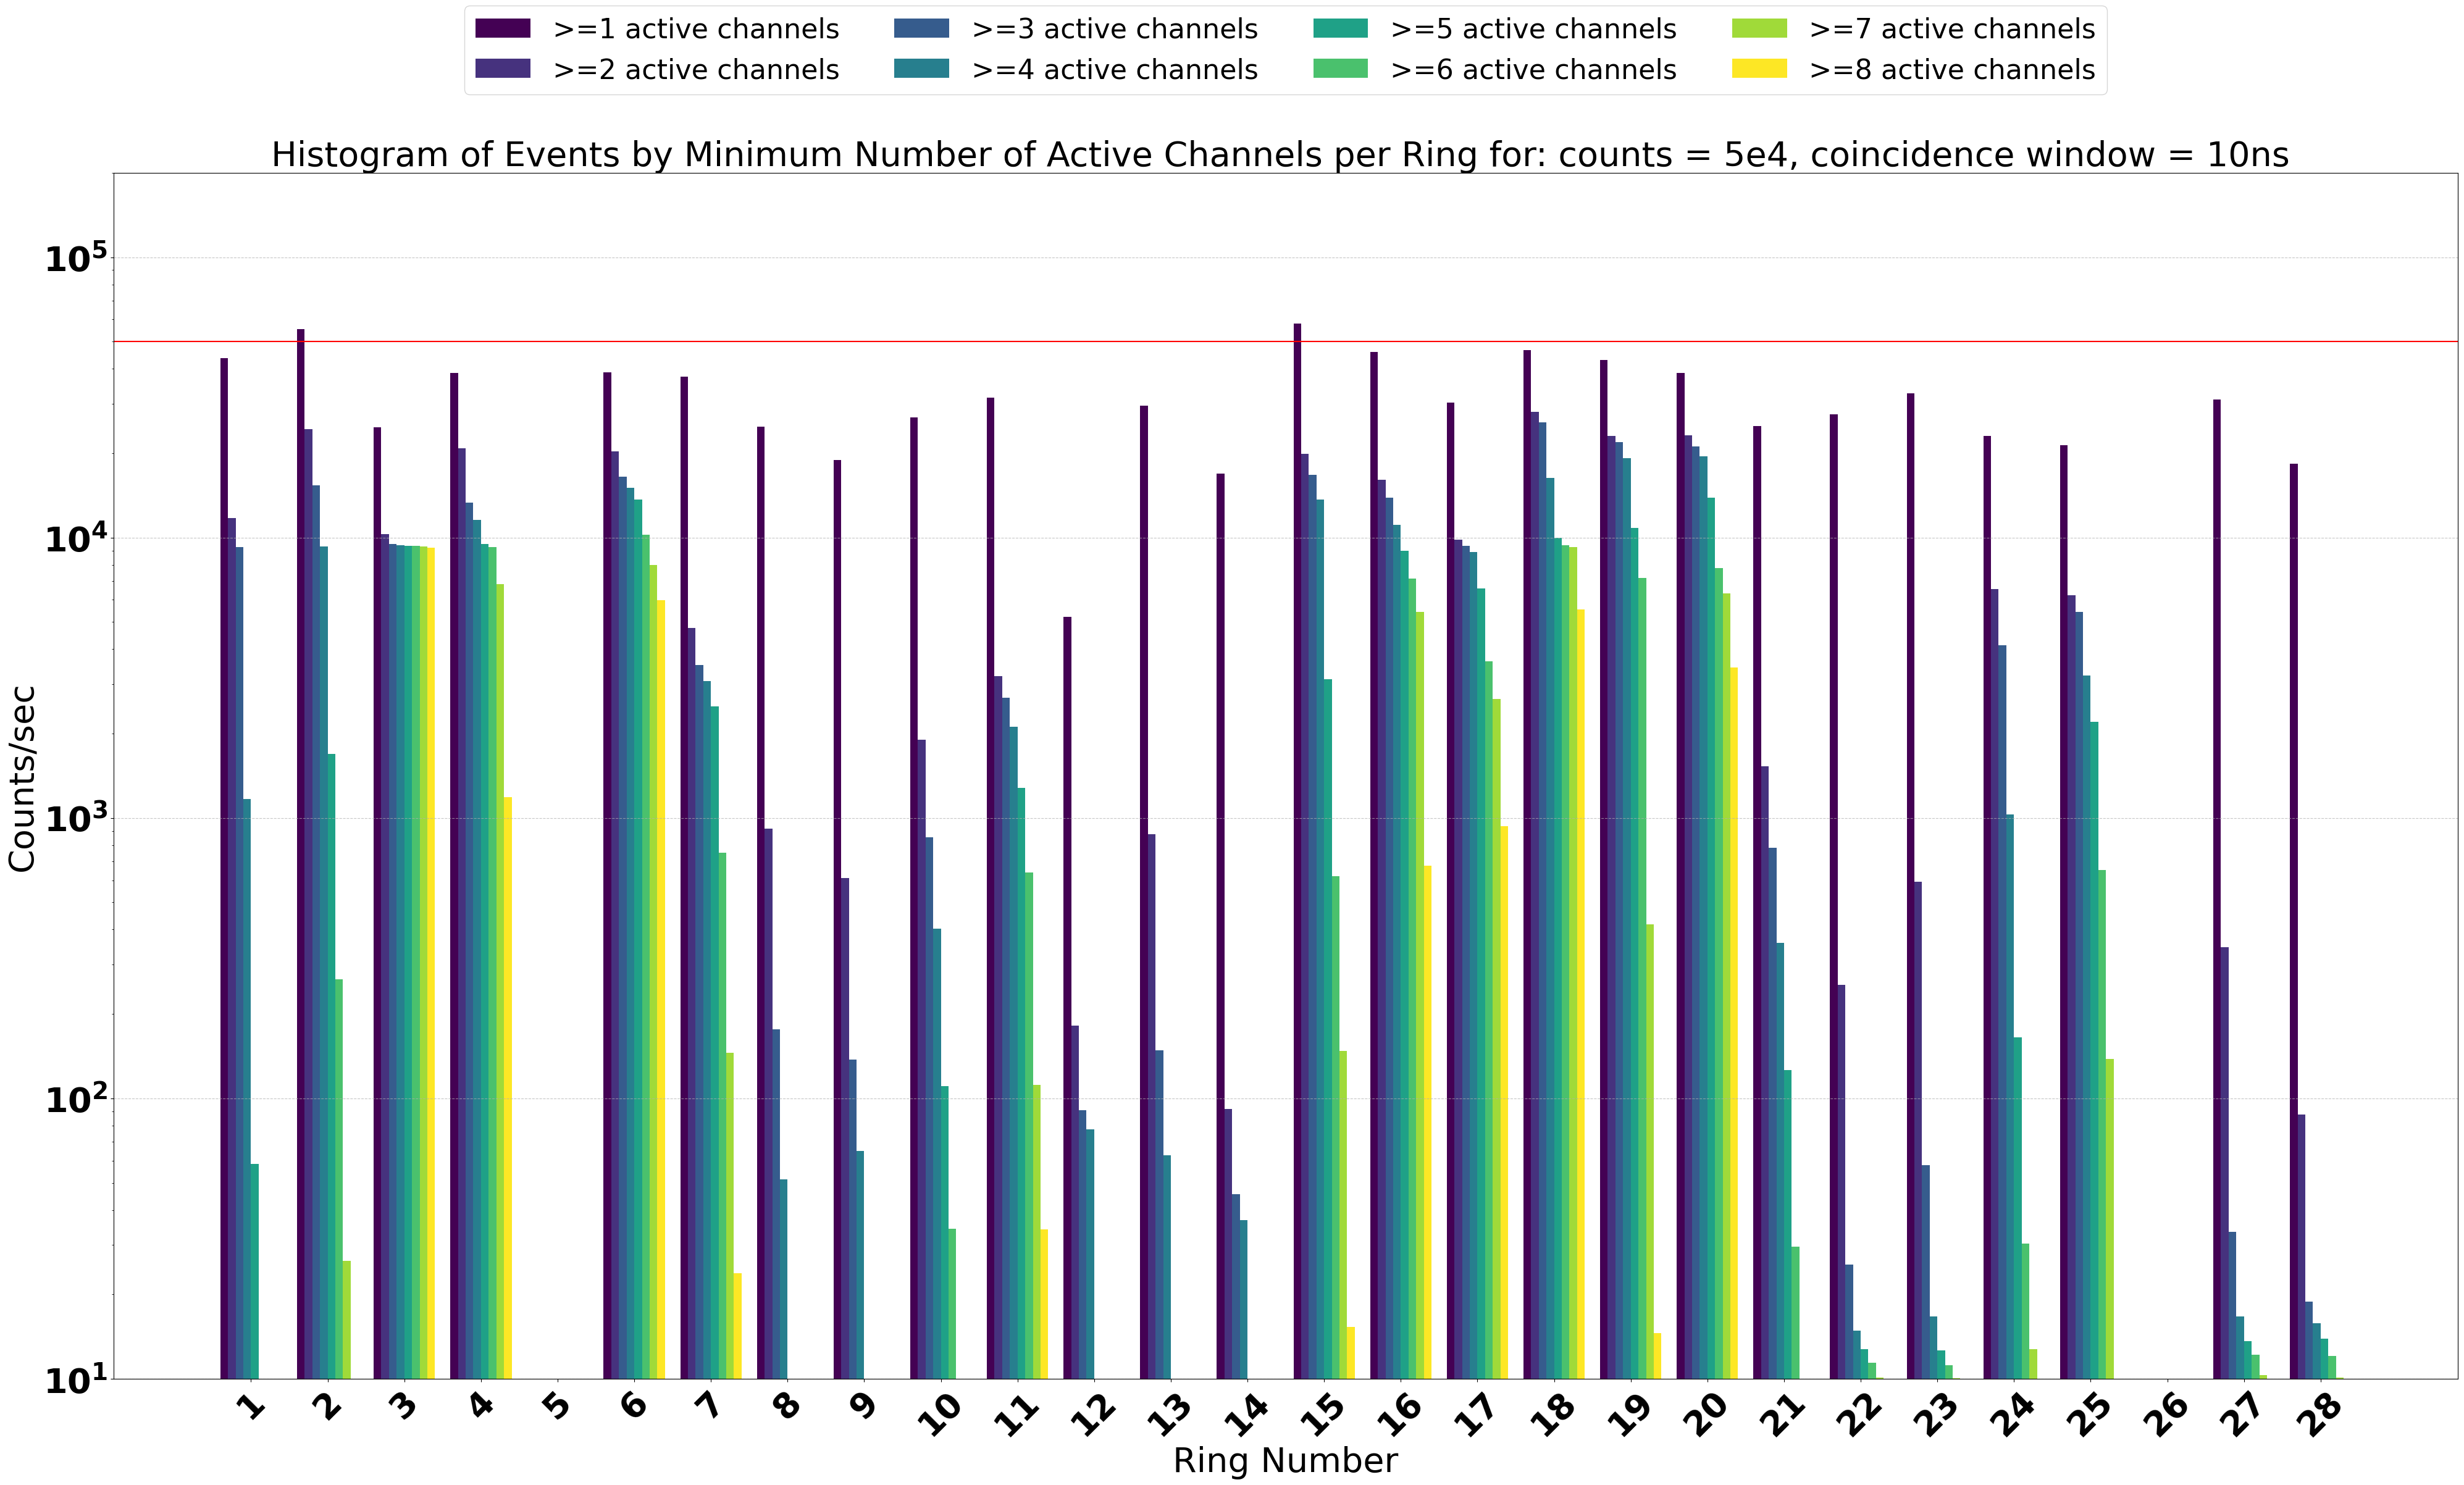

In [9]:

# ----------------------------- # Plot 2: Events vs min # active channels per ring # -----------------------------
rings = hist_df_Thresh230_5min.index
n_rings = len(rings)
x_indices = np.arange(n_rings)
bar_width = 0.1
colors = plt.cm.viridis(np.linspace(0, 1, 8))

plt.figure(figsize=(40, 24))
for i, x_thr in enumerate(range(1, 9)):
    bar_positions = x_indices + i * bar_width
    plt.bar(bar_positions, hist_df_Thresh230_5min[x_thr]/75,
            width=bar_width, color=colors[i],
            label=f'>={x_thr} active channels')

tick_positions = x_indices + 3.5 * bar_width
plt.xticks(tick_positions, rings, fontsize=40, fontweight='bold', rotation=45)
plt.xlabel('Ring Number', fontsize=40)
plt.ylabel('Counts/sec', fontsize=40)
plt.title('Histogram of Events by Minimum Number of Active Channels per Ring for: counts = 5e4, coincidence window = 10ns ', fontsize=40)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(fontsize=40, fontweight='bold')
# Legend customization
plt.legend(
    fontsize=32,
    ncol=4,                 # 4 columns (2x4 structure)
    loc='upper center',     # Anchor location
    bbox_to_anchor=(0.5, 1.15), # Position above plot
    title_fontsize=23       # Slightly larger title
)
plt.ylim(10, 2e5)  # adjust if needed
plt.axhline(y=5e4, color='red')
plt.yscale("log")
plt.tight_layout()
plt.show()

In [10]:
!ls ../Histogram_files/28_April_2026/Background_Data/

hist_Counts_50000_5min_10ns_csv_grouping2.root
hist_Counts_50000_5min_10ns_csv.root


In [11]:
# -----------------------------
# 1. Read ROOT file
# -----------------------------
hist_df_Thresh260_5min =  get_hist_df_dataframe("../Histogram_files/28_April_2026/Background_Data/hist_Counts_50000_5min_2ns_csv_grouping2.root")

print(hist_df_Thresh260_5min)

            1        2        3       4       5       6       7       8
Ring                                                                   
1     5099614   494502   332056   69157    3492     325     198     153
2     4796945  1036917   646545  417533   42648    3314     406     158
3     2319403   503277   476315  474087  473684  473148  470740  445560
4     2592474   738668   540819  486228  365373  252472  181090    9963
5           0        0        0       0       0       0       0       0
6     2908586  1100595   826581  713210  598115  426794  362605  313160
7     3112921   201628   159404  116081   22604    2896     592     252
8     4948127    32562     2806     766      68      20       8       2
9     3463152    15731     1514     738      65      39      29      24
10    2563542    28265     6632    2440     544     200      51      15
11    6039006   180831    99400   47611   14637    4069    1296     361
12    1733658     4632      848     606      36      21      13 

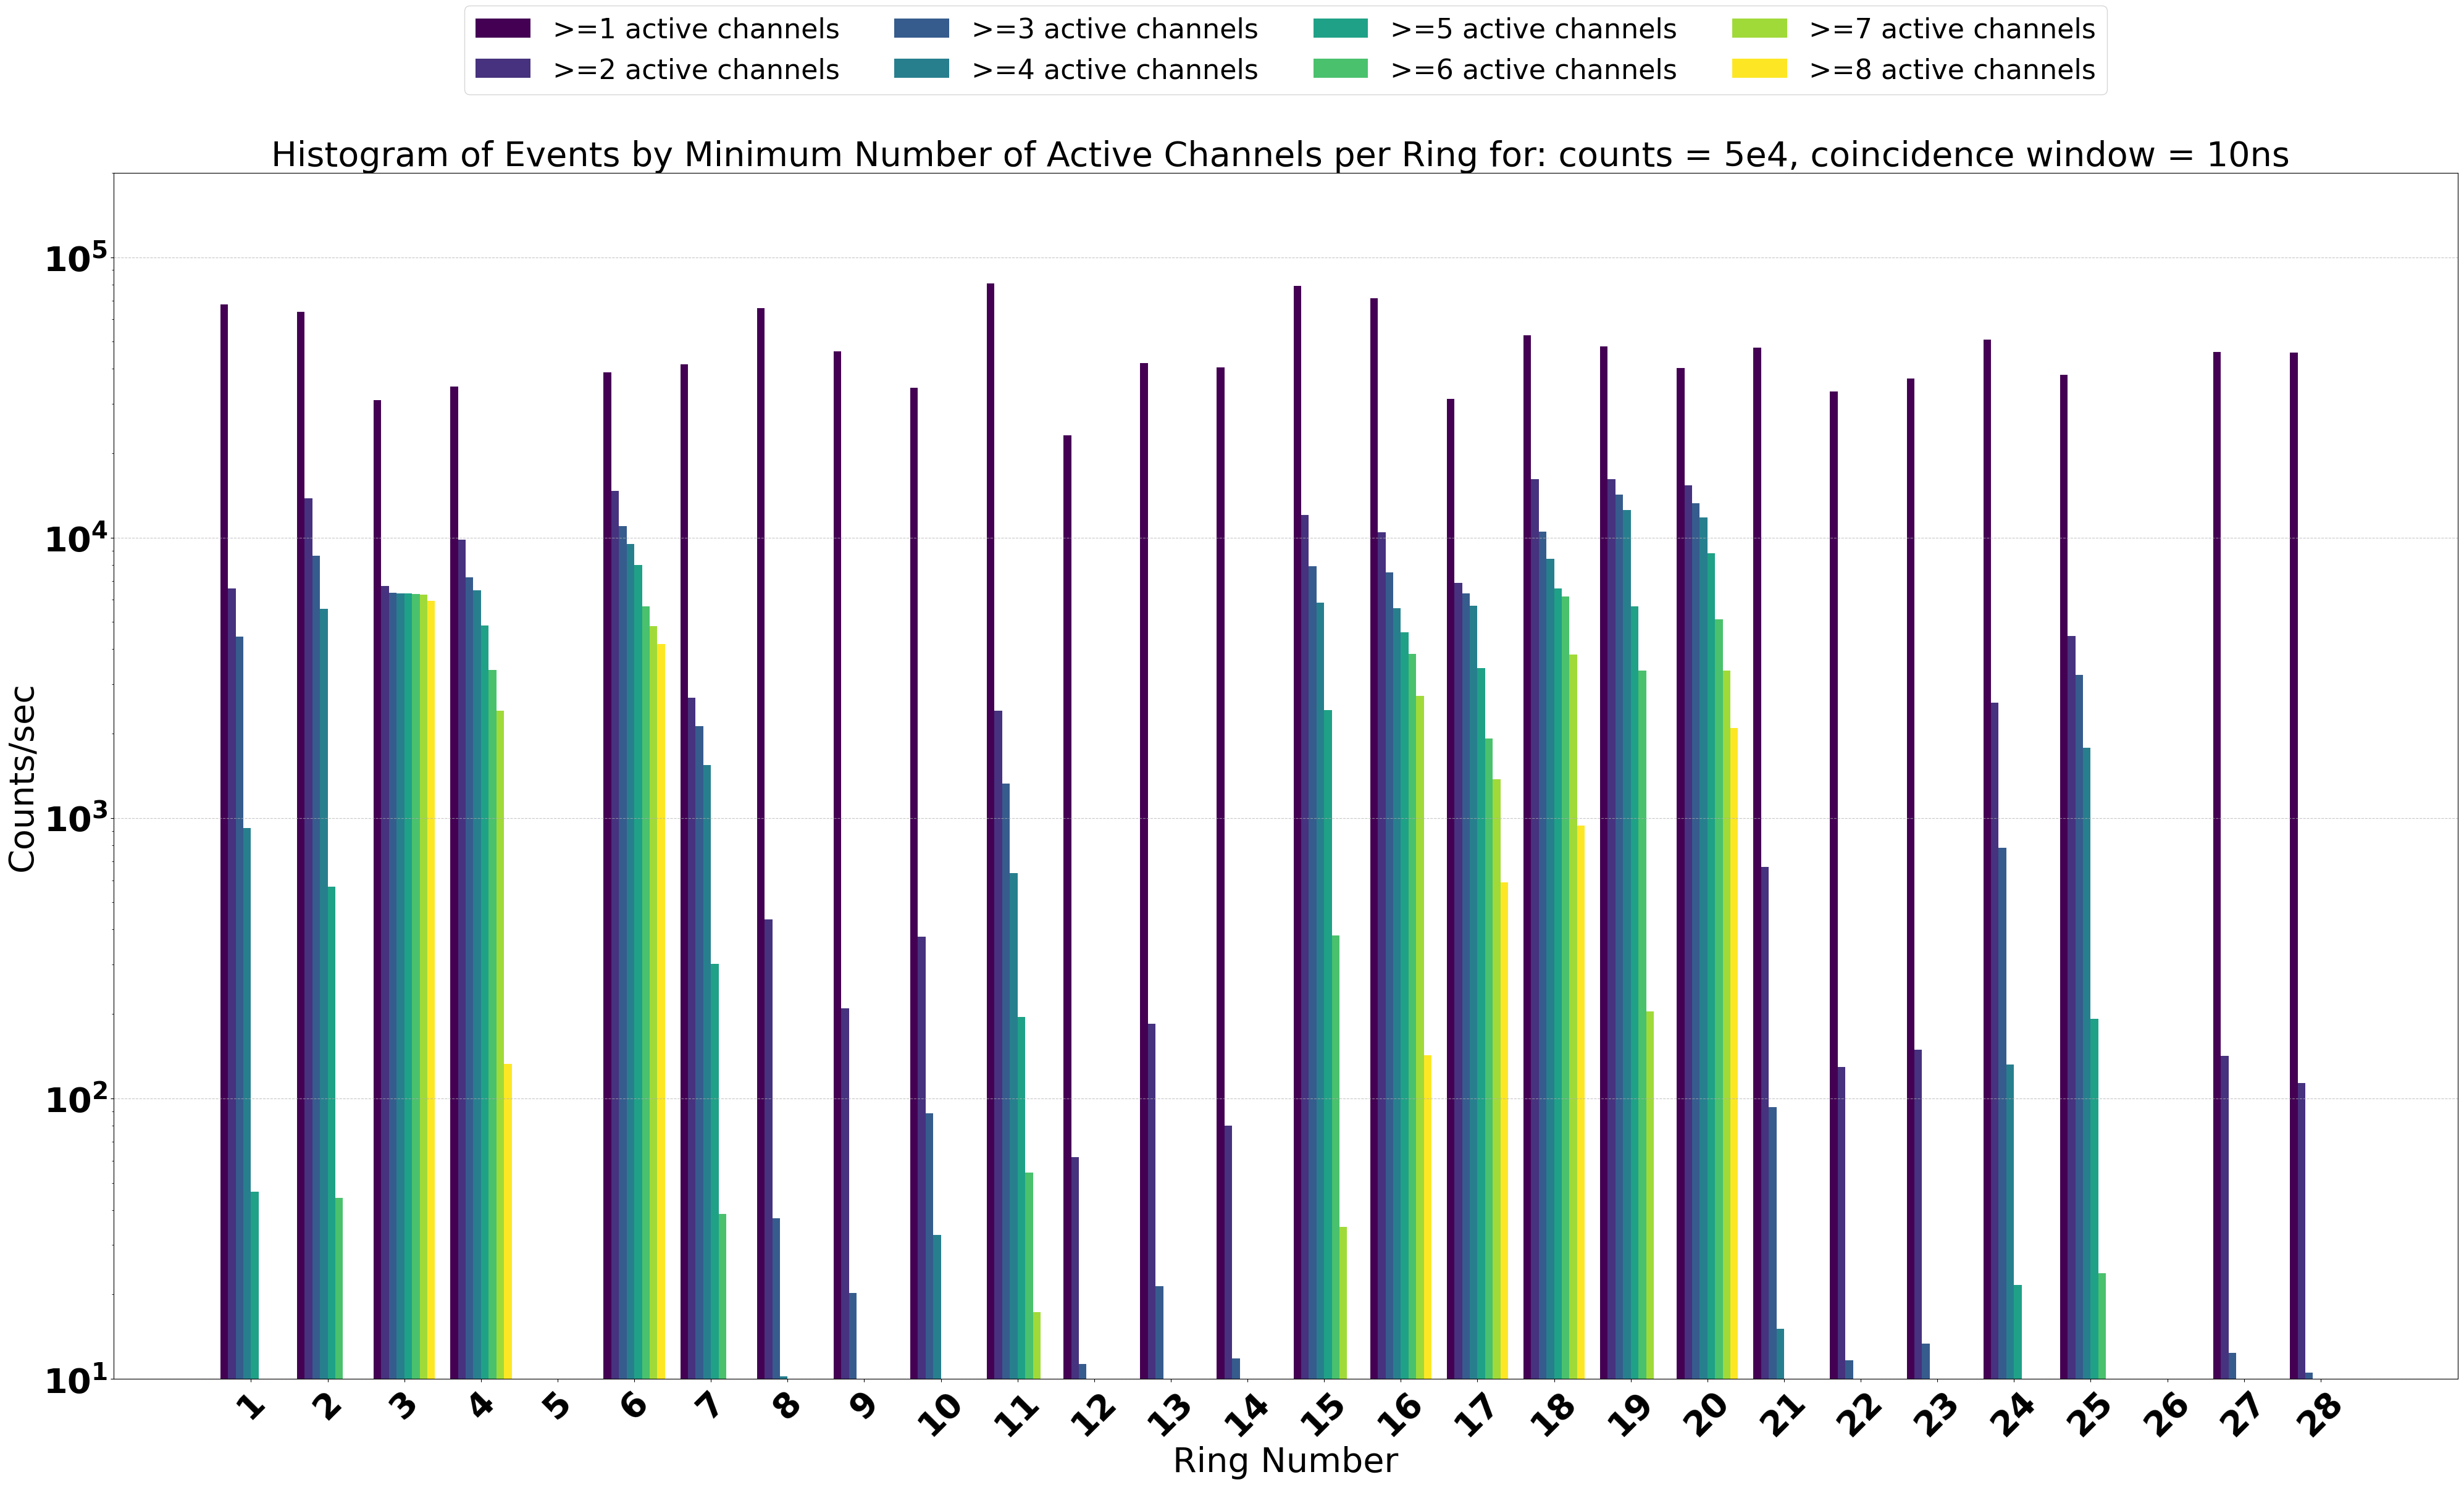

In [12]:
# ----------------------------- # Plot 2: Events vs min # active channels per ring # -----------------------------
rings = hist_df_Thresh260_5min.index
n_rings = len(rings)
x_indices = np.arange(n_rings)
bar_width = 0.1
colors = plt.cm.viridis(np.linspace(0, 1, 8))

plt.figure(figsize=(40, 24))
for i, x_thr in enumerate(range(1, 9)):
    bar_positions = x_indices + i * bar_width
    plt.bar(bar_positions, hist_df_Thresh260_5min[x_thr]/75.0,
            width=bar_width, color=colors[i],
            label=f'>={x_thr} active channels')

tick_positions = x_indices + 3.5 * bar_width
plt.xticks(tick_positions, rings, fontsize=40, fontweight='bold', rotation=45)
plt.xlabel('Ring Number', fontsize=40)
plt.ylabel('Counts/sec', fontsize=40)
plt.title('Histogram of Events by Minimum Number of Active Channels per Ring for: counts = 5e4, coincidence window = 10ns ', fontsize=40)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(fontsize=40, fontweight='bold')
# Legend customization
plt.legend(
    fontsize=32,
    ncol=4,                 # 4 columns (2x4 structure)
    loc='upper center',     # Anchor location
    bbox_to_anchor=(0.5, 1.15), # Position above plot
    title_fontsize=23       # Slightly larger title
)
plt.ylim(10, 2e5)  # adjust if needed
plt.yscale("log")
plt.tight_layout()
plt.show()

In [3]:
# -----------------------------
# 1. Read ROOT file
# -----------------------------
hist_df_Thresh260_5min_10ns = get_hist_df_dataframe("../Histogram_files/4_March_2026/hist_df_Thresh260-5min_10ns_grouping2.root")

print(hist_df_Thresh260_5min_10ns)

            1        2        3       4       5       6       7     8
Ring                                                                 
1      507584     1994     1068     946     870     792     717   608
2     1192034   397284   304865   58691    8608    1745     840   634
3     2247575  1275476  1043265  886712  656532  365457  125657  4824
4     1480004   507255    60820    4451    1282    1097     968   816
5     2718977  1998649   680491  154325   19273    2149    1040   842
6     1429140   267344    69812   15236    4736    2099    1320   938
7      859722    59143    20737    5121    2154    1510    1126   918
8     1362095     8070     3178    2417      74      48      36    27
9      389569     5372     3205    2485     122     104      80    61
10     489576     6814     3171    2404     165     125      98    77
11    3337772   511199   389602  267423  141095   30347    5069  1646
12     340151     4391     2867    2237     118      94      67    49
13    1829480     87

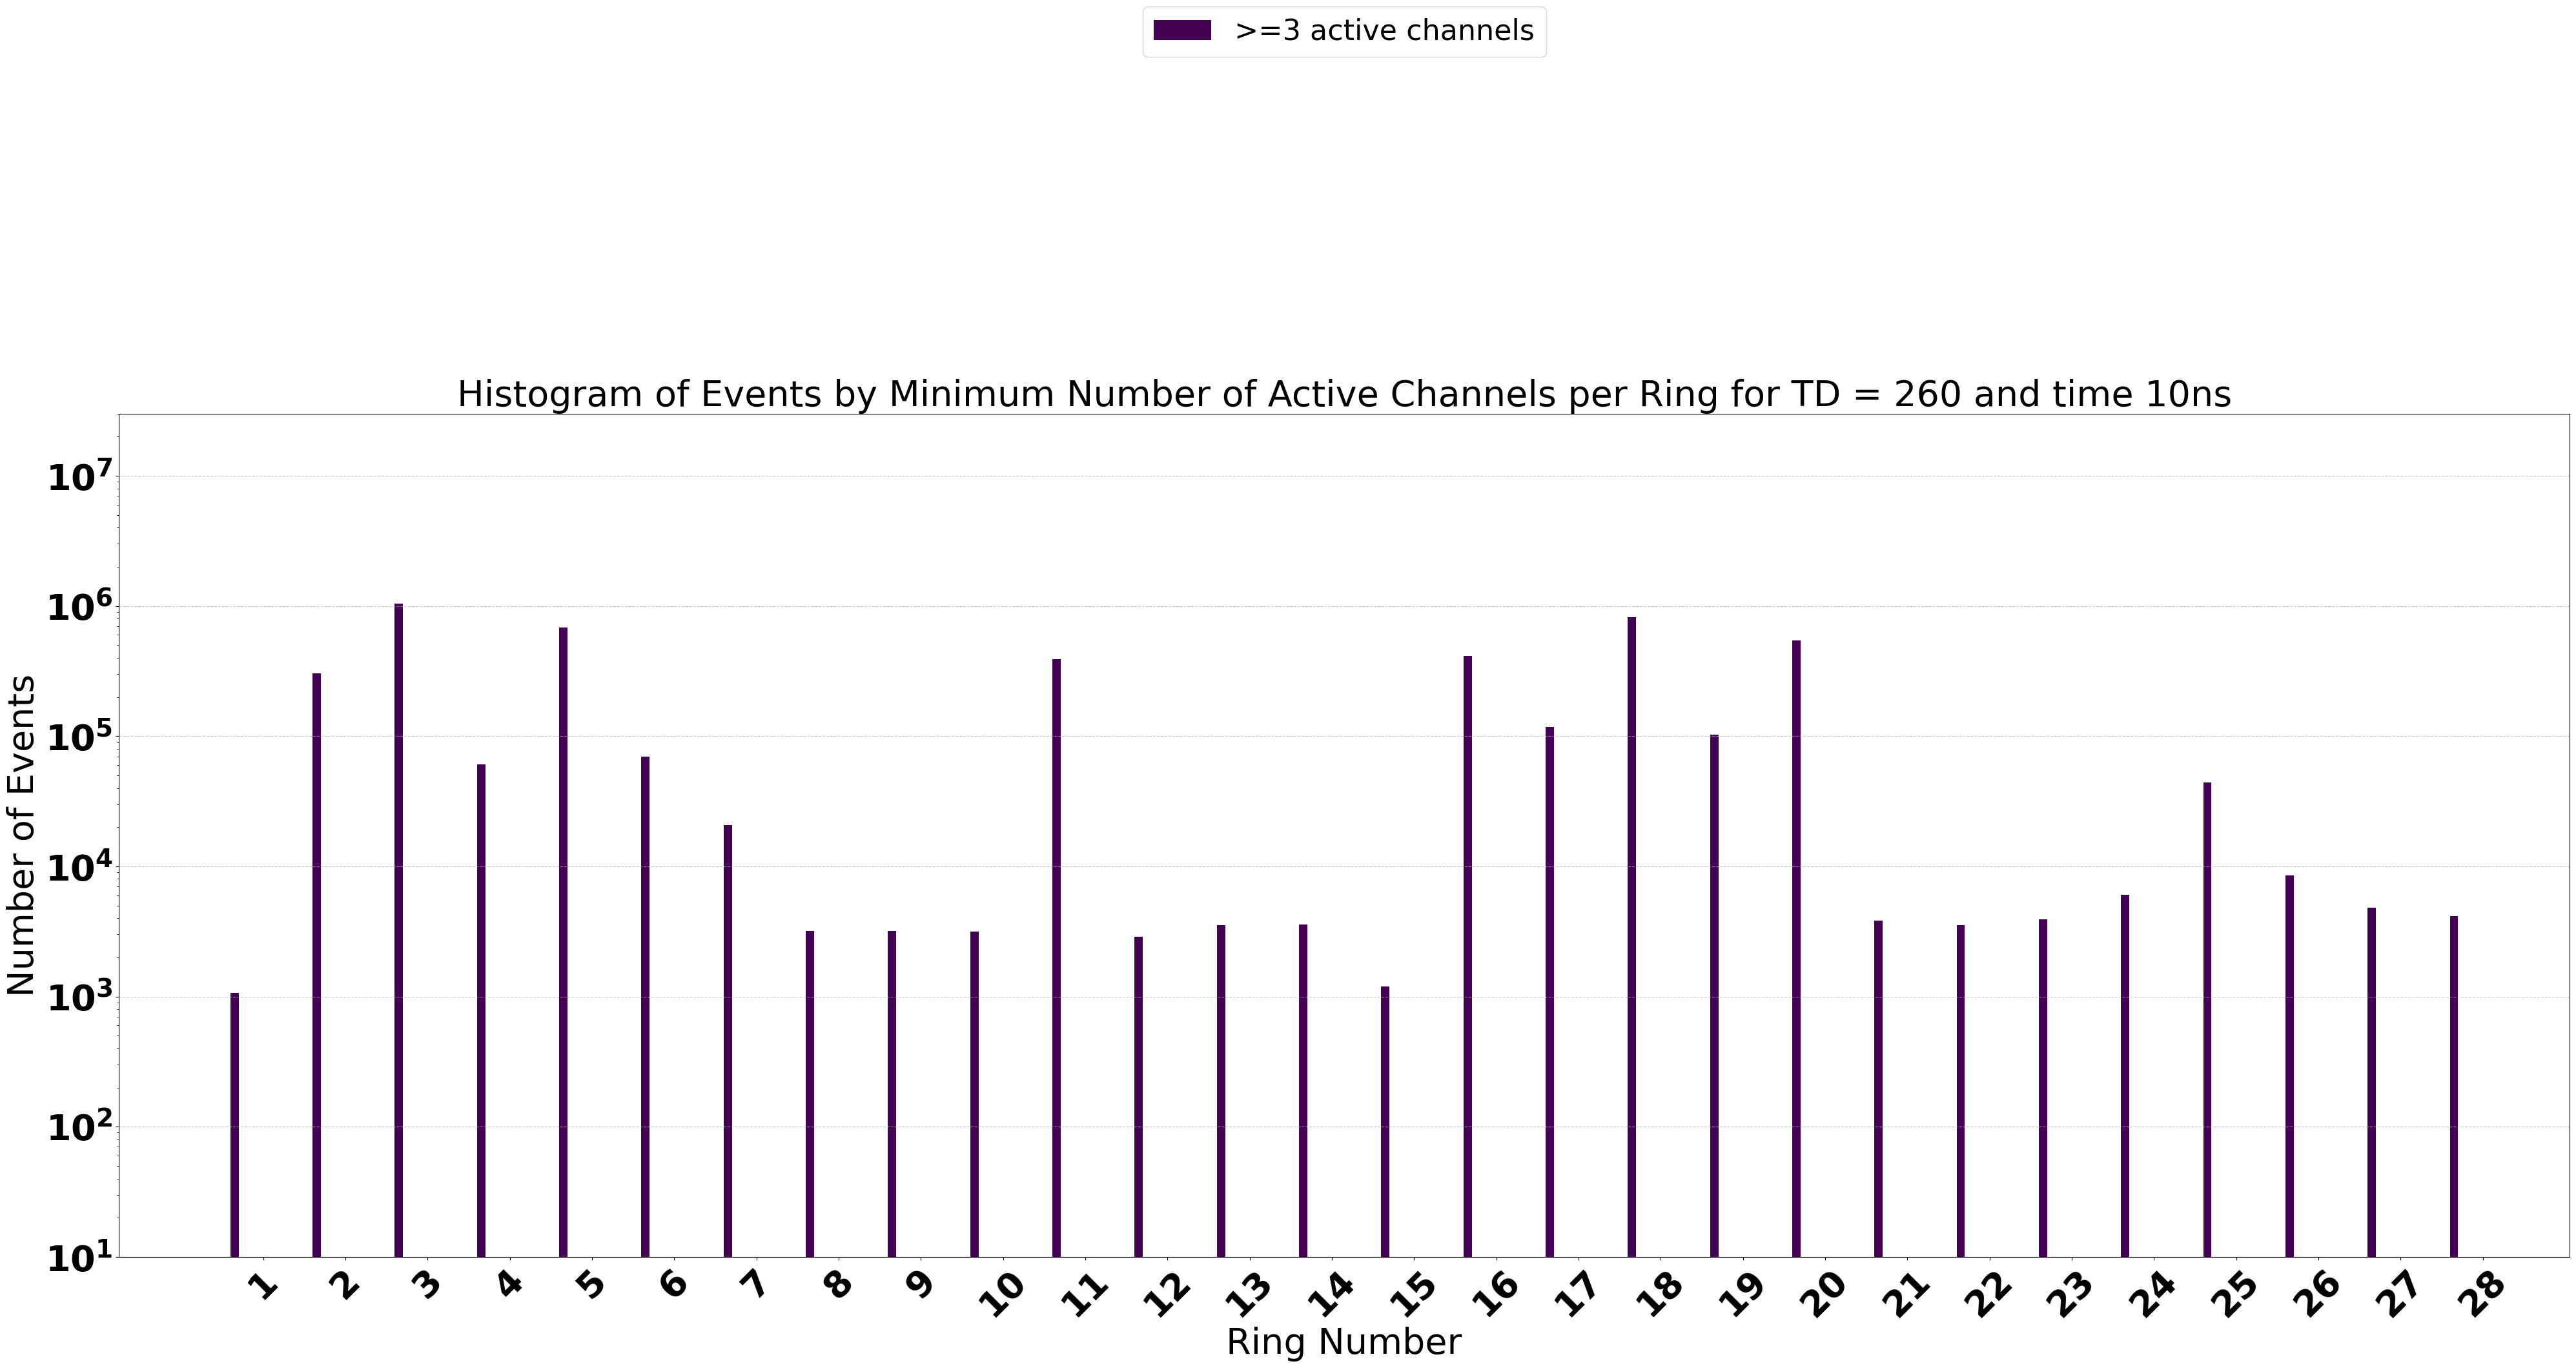

In [8]:
# ----------------------------- # Plot 2: Events vs min # active channels per ring # -----------------------------
rings = hist_df_Thresh260_5min_10ns.index
n_rings = len(rings)
x_indices = np.arange(n_rings)
bar_width = 0.1
colors = plt.cm.viridis(np.linspace(0, 1, 8))

plt.figure(figsize=(40, 24))
for i, x_thr in enumerate(range(3, 4)):
    bar_positions = x_indices + i * bar_width
    plt.bar(bar_positions, hist_df_Thresh260_5min_10ns[x_thr],
            width=bar_width, color=colors[i],
            label=f'>={x_thr} active channels')

tick_positions = x_indices + 3.5 * bar_width
plt.xticks(tick_positions, rings, fontsize=40, fontweight='bold', rotation=45)
plt.xlabel('Ring Number', fontsize=40)
plt.ylabel('Number of Events', fontsize=40)
plt.title('Histogram of Events by Minimum Number of Active Channels per Ring for TD = 260 and time 10ns', fontsize=40)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(fontsize=40, fontweight='bold')
# Legend customization
plt.legend(
    fontsize=32,
    ncol=4,                 # 4 columns (2x4 structure)
    loc='upper center',     # Anchor location
    bbox_to_anchor=(0.5, 1.5), # Position above plot
    title_fontsize=23       # Slightly larger title
)
plt.ylim(10, 3e7)  # adjust if needed
plt.yscale("log")
plt.tight_layout()
plt.show()

In [37]:
# -----------------------------
# 1. Read ROOT file
# -----------------------------
hist_df_Thresh200_5min_10ns = get_hist_df_dataframe("../ROOT_files/Thresh200-5min/hist_df_10ns.root")

print(hist_df_Thresh200_5min_10ns)

            1       2      3      4     5     6     7     8
Ring                                                       
1     6164718  513678  53498   9688  3794  2529  1622   719
2     5713376  462751  69070  21483  9022  4713  2430  1016
3     3479316  349371  50708   9628  2268   674   198    44
4     2665783  142662   8574    529    87    50    32    14
5     2345664  116546   6776    400    77    43    25    10
6     3481504  311961  55255  14980  2978   711   185    46
7     3327078  307731  60956  16556  3257   583    86    19
8     2423296  109236   5635    339    73    39    17     8
9     2706106  112512   5662    394    92    47    28    14
10    3256201  178579  20193   4670  1230   373   132    39
11    3158429  263603  43798  10268  2475   693   185    34
12    2861113  217986  21211   2987   681   201    57    15
13    2423788  114590   6355    345    40    20     9     5
14    2863527  122613   6504    371    51    22    13     5
15    6839887  473654  41489   6343  149

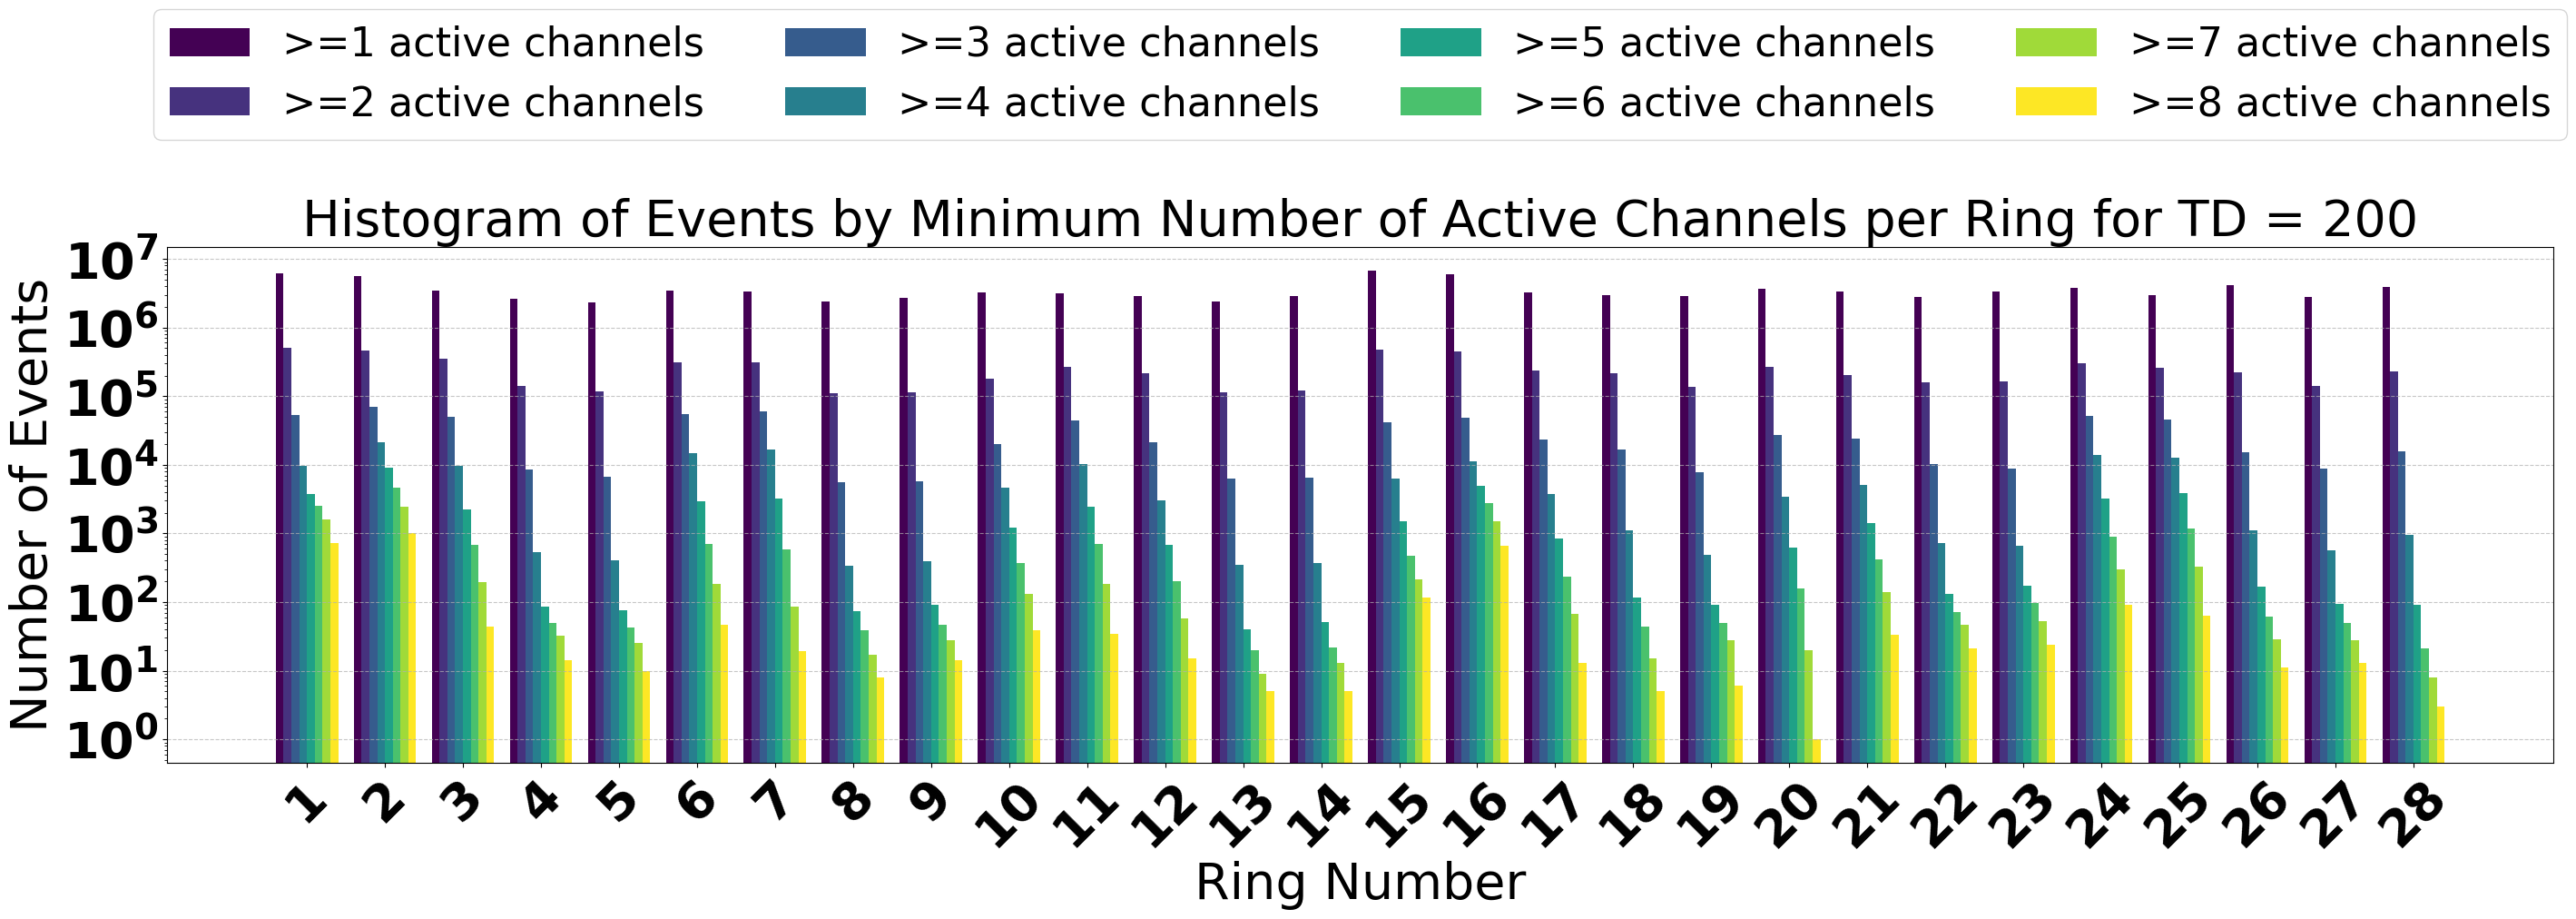

In [40]:
# ----------------------------- # Plot 2: Events vs min # active channels per ring # -----------------------------
rings = hist_df_Thresh200_5min_10ns.index
n_rings = len(rings)
x_indices = np.arange(n_rings)
bar_width = 0.1
colors = plt.cm.viridis(np.linspace(0, 1, 8))

plt.figure(figsize=(30, 12))
for i, x_thr in enumerate(range(1, 9)):
    bar_positions = x_indices + i * bar_width
    plt.bar(bar_positions, hist_df_Thresh200_5min_10ns[x_thr],
            width=bar_width, color=colors[i],
            label=f'>={x_thr} active channels')

tick_positions = x_indices + 3.5 * bar_width
plt.xticks(tick_positions, rings, fontsize=40, fontweight='bold', rotation=45)
plt.xlabel('Ring Number', fontsize=40)
plt.ylabel('Number of Events', fontsize=40)
plt.title('Histogram of Events by Minimum Number of Active Channels per Ring for TD = 200', fontsize=40)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(fontsize=40, fontweight='bold')
# Legend customization
plt.legend(
    fontsize=32,
    ncol=4,                 # 4 columns (2x4 structure)
    loc='upper center',     # Anchor location
    bbox_to_anchor=(0.5, 1.5), # Position above plot
    title_fontsize=23       # Slightly larger title
)
#plt.ylim(1000, 4e5)  # adjust if needed
plt.yscale("log")
plt.tight_layout()
plt.show()